# Getting the most out of GPT-5.4 for document and multimodal understanding

GPT-5.4 marks a meaningful leap forward for real-world multimodal workloads, with notably stronger reliability on dense, document-centric tasks such as scans, forms, charts, and technical diagrams.

Inputs that previously strained vision systems or required stitching together OCR, layout detection, and custom parsers, including dense scans, handwritten forms, engineering diagrams, and chart-heavy reports, can now often be interpreted and reasoned over in a single model pass with GPT-5.4.

However, model configuration is key for unlocking SOTA results. Small choices around image detail, verbosity, reasoning effort, and tool usage can significantly affect performance. 

This notebook covers practical patterns for building robust multimodal pipelines with GPT-5.4 and tuning them for high-performance document understanding.

## A quick decision guide

| If your task looks like this | Start with this setup | Why |
|---|---|---|
| Ordinary document QA or extraction | `detail="auto"` | Lowest-friction default for readable pages |
| Dense scans, screenshots, handwriting, or tiny labels | `detail="original"` | Preserves small visual signals that often get lost |
| Literal transcription or markdown conversion | `text={"verbosity": "high"}` | Encourages the model to keep more layout and fewer paraphrases |
| Region localization | Ask for `[x_min, y_min, x_max, y_max]` in a fixed `0..999` grid | Easy to crop, draw, debug, and feed into downstream systems |
| Chart, table, form, or drawing QA across multiple regions | increase reasoning effort to 'high' or 'xhigh' | Improves multi-step visual reasoning |
| Multi-pass visual inspection | Add Code Interpreter | Best when a human would zoom, crop, rotate, or inspect several subregions before answering |

## Setup
Start Jupyter from the `openai-cookbook` repo root so the relative paths resolve correctly.

Install the required dependencies if needed:
```bash
pip install --upgrade openai pandas pillow
```

In [3]:
import base64
import json
import mimetypes
import os
import re
import tempfile
import time
import unicodedata
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display
from PIL import Image, ImageDraw
from openai import OpenAI

client = OpenAI()

### Shared helpers

The next block defines the small utilities used throughout the notebook.


In [4]:
def image_to_data_url(image_path: str | Path) -> str:
    path = Path(image_path)
    if not path.exists():
        raise FileNotFoundError(f"Image not found: {path}")
    mime_type = mimetypes.guess_type(path.name)[0] or "image/png"
    encoded = base64.b64encode(path.read_bytes()).decode("ascii")
    return f"data:{mime_type};base64,{encoded}"


def response_usage(response) -> dict:
    usage = getattr(response, "usage", None)
    if usage is None:
        return {}
    return usage.model_dump() if hasattr(usage, "model_dump") else dict(usage)


def extract_json(text: str):
    cleaned = text.strip()
    if cleaned.startswith("```"):
        cleaned = re.sub(r"^```(?:json)?\s*", "", cleaned)
        cleaned = re.sub(r"\s*```$", "", cleaned)

    candidates = [cleaned]
    for opening, closing in [("{", "}"), ("[", "]")]:
        start = cleaned.find(opening)
        end = cleaned.rfind(closing)
        if start != -1 and end != -1 and end > start:
            candidates.insert(0, cleaned[start : end + 1])

    for candidate in candidates:
        try:
            return json.loads(candidate)
        except json.JSONDecodeError:
            continue

    raise ValueError("Response did not contain valid JSON.")


def maybe_parse_json(text: str):
    try:
        return extract_json(text)
    except ValueError:
        return None

## 1. Increase image detail for dense pages and handwriting

The `detail` parameter controls the resolution the model uses when processing an image. Most applications should start with `detail="auto"` which lets the model choose an appropriate resolution. However, when pages contain handwriting, small labels, dense tables, low contrast scans, or screenshots with fine text, switching to `detail="original"` can significantly improve results. If the model is mostly correct but consistently misses small fields or annotations, increasing image detail is usually the first adjustment to try.

This example intentionally includes small email and phone fields, not just the larger handwritten names. Those are the kinds of details that tend to degrade first when the image is downsampled.

![Handwritten insurance form](../../images/3C_insurance_form.png)


In [20]:
handwriting_prompt = """
Read the handwritten earthquake insurance application and return JSON with these keys:
- applicant_name
- applicant_email
- applicant_home_phone
- applicant_cell_phone
- co_applicant_name
- co_applicant_email
- co_applicant_home_phone
- co_applicant_work_phone
- effective_date
- expiration_date
- dwelling_coverage_limit_usd
- square_footage
- year_of_construction
"""

handwritten_form_path = f"../../images/3C_insurance_form.png"
handwritten_form_image_url = image_to_data_url(handwritten_form_path)
handwriting_model = "galapagos-alpha"

request = {
        "model": "galapagos-alpha",
        "input": [
            {
                "role": "user",
                "content": [
                    {"type": "input_text", "text": handwriting_prompt},
                    {
                        "type": "input_image",
                        "image_url": handwritten_form_image_url,
                        "detail": "original",
                    },
                ],
            }
        ],
    }
response = client.responses.create(**request)
display(Markdown(f"### Extracted Insurance Form\n\n```text\n{response.output_text}\n```"))


### Extracted Insurance Form

```text
{
  "applicant_name": "Smith, James L",
  "applicant_email": "Jsmith1@gmail.com",
  "applicant_home_phone": "510 331 5555",
  "applicant_cell_phone": "510 212 5555",
  "co_applicant_name": "Roberts, Jesse T",
  "co_applicant_email": "jrobertsjr@gmail.com",
  "co_applicant_home_phone": "510 331 5555",
  "co_applicant_work_phone": "415 626 5555",
  "effective_date": "5/31/25",
  "expiration_date": "5/31/27",
  "dwelling_coverage_limit_usd": 900000,
  "square_footage": 1200,
  "year_of_construction": 2005
}
```

## 2. Increase verbosity for faithful transcription

When asked to transcribe documents, multimodal models tend to compress layout. They preserve meaning but may simplify whitespace, line breaks, and table-like layout. This behavior is often desirable for question answering, but not for OCR-style tasks.

Increase verbosity - `text={"verbosity": "high"}` encourages the model toward a more literal rendering and precise transcription. Use it for OCR-style workloads and targeted extractions where completeness matters more than brevity.

To make the difference concrete, the cell below compares default and high verbosity on the `Ticket To The Arts` panel, asking for a full transcription of all four listings while keeping the image detail fixed.

![Newspaper clipping](images/newspaper.png)


In [19]:
section_prompt = (
    "Transcribe everything in the Ticket To The Arts section."
)

newspaper_path = "../../examples/multimodal/images/newspaper.png"
newspaper_image_url = image_to_data_url(newspaper_path)

request = {
        "model": "galapagos-alpha",
        "text": {"verbosity": "high"},
        "input": [
            {
                "role": "user",
                "content": [
                    {"type": "input_text", "text": section_prompt},
                    {
                        "type": "input_image",
                        "image_url": newspaper_image_url,
                        "detail": "high",
                    },
                ],
            }
        ],
    }
response = client.responses.create(**request)
display(Markdown(f"### Transcription preview\n\n```text\n{response.output_text}\n```"))

### Transcription preview

```text
Here is a transcription of everything visible in the **“Ticket To The Arts”** section:

---

**Ticket To The Arts**

### THEATER

**CRUMBS FROM THE TABLE OF JOY**  
LYRIC STAGE BOSTON  
BY LYNN NOTTAGE  
DIRECTED BY TASIA A. JONES

Set in 1950’s Brooklyn, two sisters mourn the loss of their mother with Hollywood films, daydreams, and lots of cookies. When a shocking decision is made by their father, the family must find new meaning in what makes a home. Tickets at lyricstage.com or by calling the box office at 617-585-5678

### MUSIC

**RUSSIAN WINTER**  
BOSTON CHAMBER MUSIC SOCIETY

Sun. 1/12 at 3PM, Sanders Theatre  
Prokofiev: Quintet in G minor, Op. 39  
Arensky: Piano Trio No. 1 in D minor, Op. 32  
Glazunov: String Quintet in A major, Op. 39  
$30-$68, Sr. $44 off, Student: $8  
617.439.0866 / bostonchambermusic.org

### MUSIC

**SPM CELEBRATES THEA MUSGRAVE**  
SYMPHONY PRO MUSICA  
Mark Churchill, Music Director

Musgraves Turbulent Landscapes, Elgar Enigma Variations, Wm. Walton Portsmouth Point. Sat Jan. 25 7:30pm Hudson High School, Sun. Jan 26 3:00pm St. John’s Founders Hall, Shrewsbury. Tix: https://www.symphonypromusica.org

### DANCE

**MARK MORRIS DANCE GROUP**  
**BACK IN BOSTON FOR THE 1ST TIME IN 6 YEARS!**

Legendary dance company Mark Morris Dance Group performs “The Look of Love”—a must-see homage to the chart-topping hits of Burt Bacharach, including “I Say a Little Prayer,” “What the World Needs Now” & more. A powerful fusion of dance and music feat. a live band and vocals sung by Broadway star Marcy Harriell, “this is choreography that, in the words of the song, says ‘more than just words could ever say’.”—The New York Times

Jan 23–26, Emerson Cutler Majestic Theatre  
For tix & info: globalartslive.org 617.876.4275

---

If you want, I can also format it as plain text only, or extract just the event titles and contact info.
```

## 3. Ask for bounding boxes in a stable format

When you need localization, do not leave the coordinate format implicit. Ask for a fixed schema like `[x_min, y_min, x_max, y_max]` and a fixed coordinate space such as `0..999` with the origin in the top-left corner.

That makes the output easy to crop, draw, debug, compare across models, and feed into downstream systems.

![Police report form](images/police_form.png)


,label,bbox
0,vehicle_1_license_plate,"[120, 309, 186, 323]"
1,vehicle_2_license_plate,"[119, 687, 192, 701]"


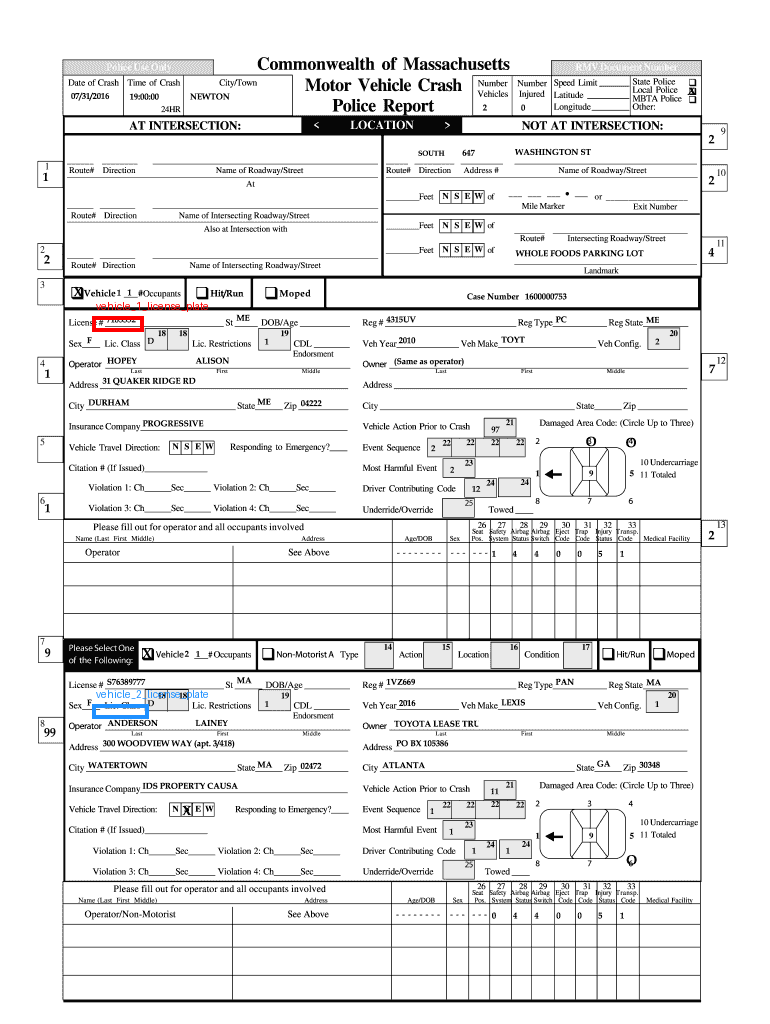

In [26]:
bbox_prompt = """
Find the license plate number for Vehicle 1 and Vehicle 2 in this police report form.
Do not guess or infer the license plate number. It is written after License #.

Return JSON with this schema:
[
  {"label": "vehicle_1_license_plate", "bbox": [x_min, y_min, x_max, y_max]},
  {"label": "vehicle_2_license_plate", "bbox": [x_min, y_min, x_max, y_max]}
]

Use discrete normalized coordinates between 0 and 999.
Return JSON only.
"""

police_form_path = f"../../examples/multimodal/images/police_form.png"
police_form_image_url = image_to_data_url(police_form_path)

bbox_response = client.responses.create(
    model="galapagos-alpha",
    reasoning={"effort": "high"},
    input=[
        {
            "role": "user",
            "content": [
                {"type": "input_text", "text": bbox_prompt},
                {
                    "type": "input_image",
                    "image_url": police_form_image_url,
                    "detail": "original",
                },
            ],
        }
    ],
)
bbox_results = maybe_parse_json(bbox_response.output_text)
if bbox_results is None:
    raise ValueError(bbox_response.output_text)

display(pd.DataFrame(bbox_results))

def denormalize_bbox(bbox: list[int], width: int, height: int) -> list[int]:
    x_min, y_min, x_max, y_max = bbox
    return [
        round(x_min * (width - 1) / 999),
        round(y_min * (height - 1) / 999),
        round(x_max * (width - 1) / 999),
        round(y_max * (height - 1) / 999),
    ]

annotated_image = Image.open(police_form_path).convert("RGB")
draw = ImageDraw.Draw(annotated_image)
width, height = annotated_image.size
palette = ["red", "dodgerblue", "limegreen", "orange", "magenta", "cyan"]

for index, item in enumerate(bbox_results):
    color = palette[index % len(palette)]
    pixel_bbox = denormalize_bbox(item["bbox"], width, height)
    draw.rectangle(pixel_bbox, outline=color, width=4)
    draw.text((pixel_bbox[0] + 4, max(0, pixel_bbox[1] - 16)), item["label"], fill=color)

display(annotated_image)


## 4. Raise reasoning effort when the image is readable but the answer is compositional

Once the image is readable, the next bottleneck is often reasoning instead of perception. That happens with charts, tables, forms, and technical drawings where the answer depends on evidence from several different parts of the page.

The floorplan below is a stand-in for a more complex architectural or CAD-style example. It has enough structure to show the tradeoff clearly while still giving us known answers.

One practical lesson from this kind of benchmark is that higher reasoning is not free. If the default pass already solves the task, turning reasoning up just adds latency. Use it selectively.

![Apartment floorplan](images/apartment_floorplan.png)


In [28]:
floorplan_prompt = """
Inspect this apartment floorplan and return JSON with these keys:
- total_named_rooms_excluding_hallways_and_closets
- largest_room
- room_immediately_east_of_kitchen
- room_immediately_south_of_study
- bedroom_1_total_area_ft2
- bedroom_2_total_area_ft2

Rules:
- Use the room labels and dimension annotations that are visible on the drawing.
- Return integers for numeric fields.
- Return JSON only.
"""

floorplan_expected = {
    "total_named_rooms_excluding_hallways_and_closets": 7,
    "largest_room": "Living Room",
    "room_immediately_east_of_kitchen": "Dining",
    "room_immediately_south_of_study": "Bedroom 2",
    "overall_width_ft": 168,
    "overall_height_ft": 96
}

floorplan_path = f"../../examples/multimodal/images/apartment_floorplan.png"
floorplan_image_url = image_to_data_url(floorplan_path)
floorplan_model = "galapagos-alpha"

request = {
        "model": floorplan_model,
        "reasoning": {"effort": "high"},
        "input": [
            {
                "role": "user",
                "content": [
                    {"type": "input_text", "text": floorplan_prompt},
                    {
                        "type": "input_image",
                        "image_url": floorplan_image_url,
                        "detail": "original",
                    },
                ],
            }
        ],
    }

response = client.responses.create(**request)
   
    
display(Markdown(f"### Floorplan Results\n\n```text\n{response.output_text}\n```"))


### Floorplan Results

```text
{
  "total_named_rooms_excluding_hallways_and_closets": 7,
  "largest_room": "Living Room",
  "room_immediately_east_of_kitchen": "Dining",
  "room_immediately_south_of_study": "Bedroom 2",
  "bedroom_1_total_area_ft2": 168,
  "bedroom_2_total_area_ft2": 96
}
```

### Chart example

The same reasoning pattern helps with chart QA. If the answer depends on reading multiple series, comparing adjacent intervals, and estimating values rather than extracting a single label, raise reasoning effort before you reach for a tool.

![Line chart](../../images/NotRealCorp_chart.png)


In [29]:
chart_prompt = """
Inspect this line chart and return JSON with these keys:
- largest_qoq_increase: {"channel": ..., "from_quarter": ..., "to_quarter": ..., "approx_delta_millions": ...}
- largest_qoq_drop: {"channel": ..., "from_quarter": ..., "to_quarter": ..., "approx_delta_millions": ...}
- fastest_growing_channel_overall

Rules:
- Use approximate values only when exact values are not printed.
- Base the answer on the visible lines and quarter labels.
- Return JSON only.
"""

chart_path = f"../../images/NotRealCorp_chart.png"
chart_image_url = image_to_data_url(chart_path)

chart_response = client.responses.create(
    model="galapagos-alpha",
    reasoning={"effort": "high"},
    input=[
        {
            "role": "user",
            "content": [
                {"type": "input_text", "text": chart_prompt},
                {
                    "type": "input_image",
                    "image_url": chart_image_url,
                    "detail": "original",
                },
            ],
        }
    ],
)
chart_json = maybe_parse_json(chart_response.output_text)
if chart_json is None:
    raise ValueError(chart_response.output_text)

print(json.dumps(chart_json, indent=2))


{
  "largest_qoq_increase": {
    "channel": "Online Sales",
    "from_quarter": "2021 Q4",
    "to_quarter": "2022 Q1",
    "approx_delta_millions": 0.15
  },
  "largest_qoq_drop": {
    "channel": "Retail Partners",
    "from_quarter": "2023 Q4",
    "to_quarter": "2024 Q1",
    "approx_delta_millions": -0.05
  },
  "fastest_growing_channel_overall": "Online Sales"
}


### Tournament bracket example

Dense tournament brackets are a good stress test for long-range visual reasoning. The model has to read mirrored trees, keep the left and right halves separate, then use the central championship score boxes to answer the actual question.

![Tournament bracket](images/bracket.png)


In [10]:
bracket_prompt = """
Inspect this tournament bracket image and return JSON with these keys:
- left_bracket_title
- right_bracket_title
- mens_champion_team
- womens_champion_team
- mens_runner_up_team
- womens_runner_up_team

Rules:
- Use the visible central championship score boxes.
- Team labels may include seeds; if you include a seed, keep it attached to the same string.
- Return JSON only.
"""

bracket_path = f"../../examples/multimodal/images/bracket.png"
bracket_image_url = image_to_data_url(bracket_path)
comparison_models = ["gpt-5", "galapagos-alpha"]

bracket_runs = []
for model in comparison_models:
    started_at = time.perf_counter()
    response = client.responses.create(
        model=model,
        input=[
            {
                "role": "user",
                "content": [
                    {"type": "input_text", "text": bracket_prompt},
                    {
                        "type": "input_image",
                        "image_url": bracket_image_url,
                        "detail": "original",
                    },
                ],
            }
        ],
    )
    elapsed_s = round(time.perf_counter() - started_at, 2)
    parsed = maybe_parse_json(response.output_text)
    usage = response_usage(response)
    bracket_runs.append(
        {
            "model": model,
            "elapsed_s": elapsed_s,
            "output_tokens": usage.get("output_tokens"),
            "parsed": parsed,
            "raw_output": response.output_text,
        }
    )

display(
    pd.DataFrame(
        [
            {
                key: result[key]
                for key in ["model", "elapsed_s", "output_tokens"]
            }
            for result in bracket_runs
        ]
    )
)

for result in bracket_runs:
    display(Markdown(f"### {result['model']} bracket output"))
    if result["parsed"] is not None:
        print(json.dumps(result["parsed"], indent=2, ensure_ascii=False))
    else:
        clipped = (
            result["raw_output"]
            if len(result["raw_output"]) <= 1800
            else result["raw_output"][:1800] + "\n\n...[truncated]..."
        )
        display(Markdown(f"### {result['model']} bracket raw output\n\n```text\n{clipped}\n```"))


,model,elapsed_s,output_tokens
0,gpt-5,27.95,1580
1,galapagos-alpha,2.42,68


### gpt-5 bracket output

{
  "left_bracket_title": "Women's Bracket",
  "right_bracket_title": "Men's Bracket",
  "mens_champion_team": "Connecticut 4",
  "womens_champion_team": "L.S.U. 3",
  "mens_runner_up_team": "5 S.D. State",
  "womens_runner_up_team": "2 Iowa"
}


### galapagos-alpha bracket output

{
  "left_bracket_title": "Women’s Bracket",
  "right_bracket_title": "Men’s Bracket",
  "mens_champion_team": "Connecticut 4",
  "womens_champion_team": "L.S.U. 3",
  "mens_runner_up_team": "5 S.D. State",
  "womens_runner_up_team": "2 Iowa"
}


### Additional interpretation examples

These two image types fit the same pattern as charts, floorplans, and brackets: the image is readable, but the answer depends on composing several visual cues into an interpretation rather than copying text.

I would not use them as public benchmark claims without verified labels and domain review, but they are still useful as additional reasoning examples and for comparing how different models explain what they see.

![ECG](images/ecg.jpg)

![Chest X-ray](images/CXR.jpeg)


In [40]:
medical_cases = [
    {
        "name": "ecg",
        "path": "../../examples/multimodal/images/ecg.jpg",
        "prompt": (
            "A 26-year-old otherwise healthy man presents to the emergency department "
            "with a 3- to 4-hour history of left-sided chest pain. The pain is pleuritic "
            "and accompanied by nausea and discomfort in the left arm. The patient denies "
            "dyspnea, diaphoresis, fever, chills, headache, diarrhea, leg swelling, and "
            "myalgia. There is no recent history of upper respiratory tract infection, "
            "contact with ill persons, or trauma. What is the most likely dx given the EKG attached?"
        ),
    },
    {
        "name": "cxr",
        "path": "../../examples/multimodal/images/CXR.jpeg",
        "prompt": "Analyze CXR and provide the most likely diagnosis",
    },
]

medical_runs = []
for case in medical_cases:
    image_url = image_to_data_url(case["path"])
    for model in ["galapagos-alpha"]:
        started_at = time.perf_counter()
        response = client.responses.create(
            model=model,
            reasoning={"effort": "high"},
            text={"verbosity": "high"},
            input=[
                {
                    "role": "user",
                    "content": [
                        {"type": "input_text", "text": case["prompt"]},
                        {
                            "type": "input_image",
                            "image_url": image_url,
                            "detail": "original",
                        },
                    ],
                }
            ],
        )
        elapsed_s = round(time.perf_counter() - started_at, 2)
        usage = response_usage(response)
        medical_runs.append(
            {
                "case": case["name"],
                "model": model,
                "elapsed_s": elapsed_s,
                "output_tokens": usage.get("output_tokens"),
                "text": response.output_text,
            }
        )

display(pd.DataFrame(medical_runs)[["case", "model", "elapsed_s", "output_tokens"]])

for run in medical_runs:
    clipped = run["text"] if len(run["text"]) <= 2200 else run["text"][:2200] + "\n\n...[truncated]..."
    display(Markdown(f"### {run['case']} - {run['model']}\n\n```text\n{clipped}\n```"))


,case,model,elapsed_s,output_tokens
0,ecg,galapagos-alpha,58.19,3841
1,cxr,galapagos-alpha,10.14,666


### ecg - galapagos-alpha

```text
The **most likely diagnosis is acute pericarditis**.

Why this fits:
- **Pleuritic chest pain** in a young man is classic for pericarditis
- The ECG appears to show **diffuse, concave ST-segment elevation**
- There are **no clear territorial reciprocal changes** to suggest a STEMI
- This pattern is much more consistent with **stage I acute pericarditis** than acute MI

Key ECG clues that favor pericarditis:
- **Widespread ST elevation** rather than elevation confined to one coronary territory
- **Concave upward ST segments**
- Possible **PR-segment depression** and **ST depression in aVR/V1**, which are supportive of pericarditis

Main differential:
- **Benign early repolarization** can look similar in a healthy 26-year-old, but with **acute pleuritic chest pain**, pericarditis is the better clinical diagnosis.

So the best answer is: **acute pericarditis**.
```

### cxr - galapagos-alpha

```text
The chest X-ray most likely shows **mild hyperinflation with central/perihilar peribronchial thickening**, **without focal lobar consolidation or pleural effusion**.

### Most likely diagnosis
**Reactive airways disease / asthma**  
**or**  
**viral bronchiolitis**  

These two often have very similar CXR appearances, and the distinction is usually made from the **patient’s age and clinical picture**.

### Why
- Lungs appear **mildly hyperexpanded**
- **Prominent perihilar/peribronchial interstitial markings / peribronchial thickening**
- **No focal dense air-space opacity** to suggest bacterial pneumonia
- No pleural effusion or pneumothorax
- Cardiomediastinal silhouette is not enlarged

### Impression
**CXR pattern is most consistent with viral bronchiolitis / reactive airways disease (asthma), with no focal pneumonia.**

If you want, I can also give this in a formal **radiology report format**.
```

## 5. Use Code Interpreter when the task needs a real second look

Native vision is often enough. Code Interpreter becomes useful when a human would open the image in another tab, zoom into several regions, rotate something, or sanity-check a reading before answering.

Reach for Code Interpreter when:

- the page is dense and the relevant evidence is scattered across multiple regions
- you expect to crop, zoom, rotate, or inspect intermediate views
- qualitative accuracy matters more than minimum latency

While drafting this notebook on March 4, 2026, the tool-assisted version of this police-form task took about `104.8s` and made `2` Code Interpreter calls. That is useful evidence, but it is not a generic speed story. Treat Code Interpreter here as a multi-pass inspection tool with an explicit latency tradeoff, not a free performance win.

The cell below compares a native pass with a tool-assisted pass on the same police-form question. This is opt-in because tool calls are slower and more expensive than a single native vision pass.


In [ ]:
ci_prompt = """
Read the police report form and look for the travel direction and damaged area code for each vehicle.
The travel direction is written after VehicleTravel Direction.
The damaged area code is circled in black in the car diagram.
Do not guess or infer the travel direction or damaged area code.

Return JSON with these keys:
- vehicle_1_travel_direction
- vehicle_1_damaged_area_code
- vehicle_2_travel_direction
- vehicle_2_damaged_area_code

Rules:
- If the form is hard to read, inspect the relevant regions before answering.
- Return JSON only.
"""

run_code_interpreter_comparison = False
ci_model = "galapagos-alpha"
police_form_path = f"../../examples/multimodal/images/police_form.png"
police_form_image_url = image_to_data_url(police_form_path)

if run_code_interpreter_comparison:
    native_started = time.perf_counter()
    native_response = client.responses.create(
        model=ci_model,
        reasoning={"effort": "high"},
        input=[
            {
                "role": "user",
                "content": [
                    {"type": "input_text", "text": ci_prompt},
                    {
                        "type": "input_image",
                        "image_url": police_form_image_url,
                        "detail": "original",
                    },
                ],
            }
        ],
    )
    native_elapsed = round(time.perf_counter() - native_started, 2)

    with police_form_path.open("rb") as asset_file:
        uploaded_file = client.files.create(file=asset_file, purpose="user_data")

    ci_started = time.perf_counter()
    ci_response = client.responses.create(
        model=ci_model,
        instructions=(
            "You are an expert document analyst. Use Code Interpreter before answering. "
            "Inspect the uploaded file, crop or zoom if needed, then answer in JSON."
        ),
        tools=[
            {
                "type": "code_interpreter",
                "container": {
                    "type": "auto",
                    "memory_limit": "4g",
                    "file_ids": [uploaded_file.id],
                },
            }
        ],
        include=["code_interpreter_call.outputs"],
        input=[
            {
                "role": "user",
                "content": [
                    {"type": "input_text", "text": ci_prompt + " Use the tool at least once before answering."},
                    {
                        "type": "input_image",
                        "image_url": police_form_image_url,
                        "detail": "original",
                    },
                ],
            }
        ],
    )
    ci_elapsed = round(time.perf_counter() - ci_started, 2)

    ci_call_count = sum(
        1
        for item in (ci_response.output or [])
        if (item.get("type") if isinstance(item, dict) else getattr(item, "type", None))
        == "code_interpreter_call"
    )

    comparison_df = pd.DataFrame(
        [
            {
                "mode": "native vision",
                "elapsed_s": native_elapsed,
                "code_interpreter_calls": 0,
                "output_tokens": response_usage(native_response).get("output_tokens"),
            },
            {
                "mode": "code interpreter",
                "elapsed_s": ci_elapsed,
                "code_interpreter_calls": ci_call_count,
                "output_tokens": response_usage(ci_response).get("output_tokens"),
            },
        ]
    )
    display(comparison_df)
    native_clipped = (
        native_response.output_text
        if len(native_response.output_text) <= 1800
        else native_response.output_text[:1800] + "\n\n...[truncated]..."
    )
    display(Markdown(f"### Native vision output\n\n```text\n{native_clipped}\n```"))

    ci_clipped = (
        ci_response.output_text
        if len(ci_response.output_text) <= 1800
        else ci_response.output_text[:1800] + "\n\n...[truncated]..."
    )
    display(Markdown(f"### Code Interpreter output\n\n```text\n{ci_clipped}\n```"))
else:
    print(
        "Skipping the Code Interpreter comparison. Set run_code_interpreter_comparison = True "
        "if you want to measure native vs tool-assisted latency on the police-form task."
    )


## 6. If you cannot use Code Interpreter, build a narrow crop-and-rerun pipeline

In restricted environments, you may not want to grant the model a general Python sandbox. A practical alternative is a two-stage workflow:

1. localize the field or region you care about
2. crop that region locally
3. rerun a smaller, more focused prompt on the crop

This often recovers much of the value of multi-pass inspection while keeping the control surface small.


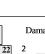

[
  "22"
]


In [32]:
police_form_path = f"../../examples/multimodal/images/police_form.png"

target_region = next(
    item for item in bbox_results if item["label"] == "vehicle_2_damaged_area_code"
)

source_image = Image.open(police_form_path).convert("RGB")
width, height = source_image.size

def denormalize_bbox(bbox: list[int], width: int, height: int) -> list[int]:
    x_min, y_min, x_max, y_max = bbox
    return [
        round(x_min * (width - 1) / 999),
        round(y_min * (height - 1) / 999),
        round(x_max * (width - 1) / 999),
        round(y_max * (height - 1) / 999),
    ]

x_min, y_min, x_max, y_max = denormalize_bbox(target_region["bbox"], width, height)
pad_x = round((x_max - x_min) * 0.18)
pad_y = round((y_max - y_min) * 0.18)

crop = source_image.crop(
    (
        max(0, x_min - pad_x),
        max(0, y_min - pad_y),
        min(width, x_max + pad_x),
        min(height, y_max + pad_y),
    )
)

tmp = tempfile.NamedTemporaryFile(suffix=".png", delete=False)
crop_path = Path(tmp.name)
tmp.close()
crop.save(crop_path)

display(crop)

crop_prompt = """
Read the circled damaged-area code or codes in this cropped police-form region.

Return JSON with one key:
- damaged_area_codes: an array of strings

Return JSON only.
"""

crop_image_url = image_to_data_url(crop_path)

crop_response = client.responses.create(
    model="galapagos-alpha",
    input=[
        {
            "role": "user",
            "content": [
                {"type": "input_text", "text": crop_prompt},
                {
                    "type": "input_image",
                    "image_url": crop_image_url,
                    "detail": "original",
                },
            ],
        }
    ],
)
crop_json = maybe_parse_json(crop_response.output_text)
if crop_json is None:
    raise ValueError(crop_response.output_text)

print(json.dumps(crop_json, indent=2))


## Guidance for Best Practices

Start with native vision when:
- the question is simple
- the page is not especially dense
- you care most about speed and cost

Add Code Interpreter when:
- the model needs multiple inspections
- the page is small, rotated, or cluttered
- you want the model to verify a reading instead of relying on one pass
- qualitative accuracy matters more than minimal token usage

Increase reasoning, even without Python, when:
- the answer depends on multiple regions of a chart, table, or form
- the task is analytical rather than pure transcription
- you can afford extra reasoning tokens for higher confidence

Expose lightweight visual tools instead of Code Interpreter when:
- you are operating in a restricted or self-hosted environment
- you want tighter control over what image transformations are allowed
- you only need crop, zoom, rotate, or an optional OCR-region fallback